# Formatting and cleaning

# [1- Load basic modules and the csv file](#1)

## 1. Load basic modules and the csv file 

In [3]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler


data = pd.read_csv('../Health_insurance/train.csv')
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 2. Checking Dataset Shape,  null Values and feature types

**Fixing incorrect, incomplete, duplicate or otherwise erroneous data**

In [2]:
data.shape

(381109, 12)

In [35]:
data.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
log_premium             0
dtype: int64

In [4]:
data.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

## 3. Importing functions from Cleaning_functions.ipynb

In [ ]:
import sys
sys.path.append('../src/')
import Cleaning_functions as cf

## 4. Categorical variables

**no nulls, both categorical and continues data**
Gender: categorical, balance
Age: continous, left skewed
Driving_License: categorical unbalance (99.78% yes)
Region_Code: categorica, ????
Previously_Insured: categorical 54% no%
Vehicle_Age: categorical, 1 variable more unbalance
Vehicle_Damage: categorical, 51% yes
Annual_Premium: continues, ¿outliers?
Policy_Sales_Channel: agrupar primeros 5, otros agruparlos en "Otros"
Vintage: continues, uniform distribution
Response: target, unbalance, 87% no




**armar workflow claro de tareas**

- EDA / Gráficos
- Preprocessing para modelar
- Modelos
- Análisis módelos


TRAIN TEST CSV --> qué hacer?


CHECK OUTLIERS
¿usar formula rango intercuartil para eliminar outliers?

DROP UNIMPORTANT COLUMNS  // Feature selection
Id, Policy sales channel, region code ?

CONVERT STRINGS TO NUMERICAL VALUES
En script clean
SCALING
En script clean

Target desbalanceado --> SMOTE

Gráficos
jugar con variables (hacer categorias, etc)
¿qué me aporta correlación? ¿otros métodos? chi2, Mutual_info_classif


Distribución no normal en mayoria features numericas

In [4]:
data['Gender'].value_counts(normalize = True) 

Male      0.540761
Female    0.459239
Name: Gender, dtype: float64

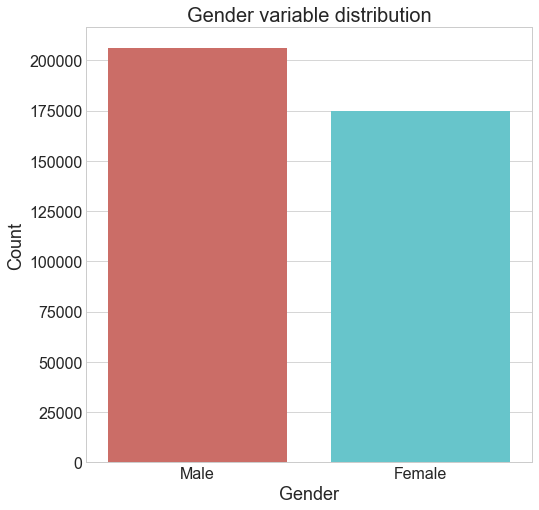

In [5]:
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize = (8, 8))

sns.countplot(x = 'Gender', data = data, palette = 'hls')

plt.title("Gender variable distribution", fontsize = 20)
plt.xlabel("Gender", fontsize = 18)
plt.ylabel("Count", fontsize = 18)

plt.yticks(fontsize = 16)
plt.xticks(ticks = [0,1] , fontsize = 16)

plt.show()

In [6]:
#data['Gender'] = data['Gender'].replace({'Male': 0, 'Female': 1})


<AxesSubplot:>

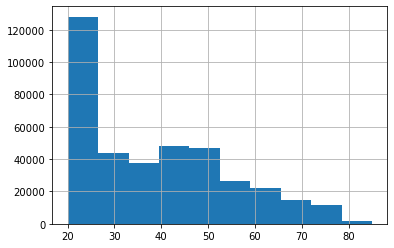

In [5]:
data['Age'].hist()

In [10]:
data['Driving_License'].value_counts(normalize = True) * 100

1    99.786938
0     0.213062
Name: Driving_License, dtype: float64

In [11]:
data['Driving_License'] = data['Driving_License'].replace({1: 'Yes', 0: 'No'})


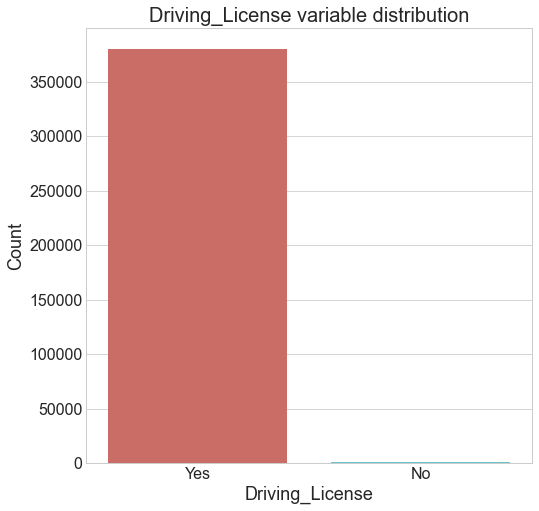

In [12]:
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize = (8, 8))

sns.countplot(x = 'Driving_License', data = data, palette = 'hls')

plt.title("Driving_License variable distribution", fontsize = 20)
plt.xlabel("Driving_License", fontsize = 18)
plt.ylabel("Count", fontsize = 18)

plt.yticks(fontsize = 16)
plt.xticks(ticks = [0,1] , fontsize = 16)

plt.show()

In [14]:
#data['Region_Code'].value_counts()

In [9]:
data['Previously_Insured'].value_counts(normalize = True) * 100

0    54.178988
1    45.821012
Name: Previously_Insured, dtype: float64

In [43]:
data['Previously_Insured'] = data['Previously_Insured'].replace({0: 'No', 1: 'Yes'})


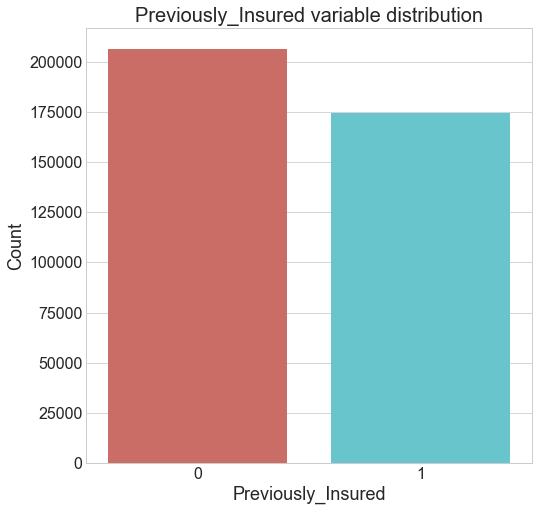

In [10]:
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize = (8, 8))

sns.countplot(x = 'Previously_Insured', data = data, palette = 'hls')

plt.title("Previously_Insured variable distribution", fontsize = 20)
plt.xlabel("Previously_Insured", fontsize = 18)
plt.ylabel("Count", fontsize = 18)

plt.yticks(fontsize = 16)
plt.xticks(ticks = [0,1] , fontsize = 16)

plt.show()

In [11]:
#cambiarla a número

data['Vehicle_Age'].value_counts(normalize = True) * 100

1-2 Year     52.561341
< 1 Year     43.238549
> 2 Years     4.200111
Name: Vehicle_Age, dtype: float64

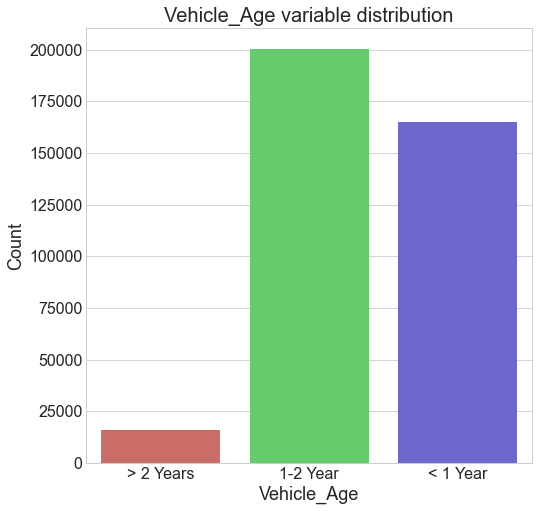

In [15]:
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize = (8, 8))

sns.countplot(x = 'Vehicle_Age', data = data, palette = 'hls')

plt.title("Vehicle_Age variable distribution", fontsize = 20)
plt.xlabel("Vehicle_Age", fontsize = 18)
plt.ylabel("Count", fontsize = 18)

plt.yticks(fontsize = 16)
plt.xticks(ticks = [0,1,2] , fontsize = 16)

plt.show()

In [13]:
#data['Vehicle_Age'] = data['Vehicle_Age'].replace({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})


In [14]:
data['Vehicle_Damage'].value_counts(normalize = True) * 100

Yes    50.487656
No     49.512344
Name: Vehicle_Damage, dtype: float64

In [15]:
#data['Vehicle_Damage'] = data['Vehicle_Damage'].replace({'No': 0, 'Yes': 1})


<AxesSubplot:>

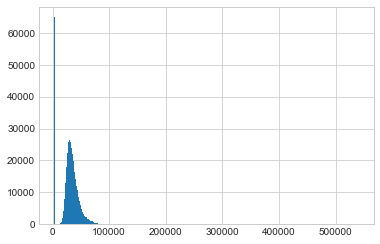

In [16]:
data['Annual_Premium'].hist(bins = 300)

/Users/maia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Annual_Premium', ylabel='Density'>

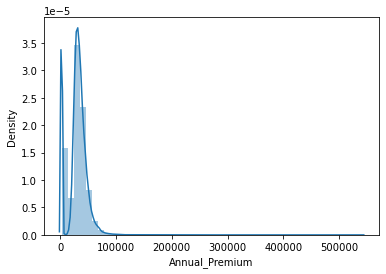

In [4]:
sns.distplot(data.Annual_Premium)


/Users/maia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='log_premium', ylabel='Density'>

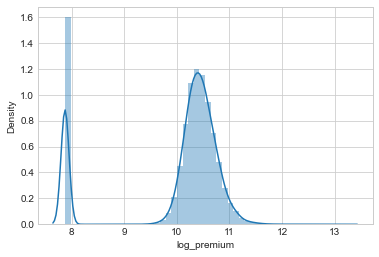

In [11]:
sns.distplot(data.log_premium)


In [12]:
data_mask = data['log_premium'] > 9
data['Annual_Premium_new'] = data[data_mask]

ValueError: Wrong number of items passed 13, placement implies 1

In [10]:
data['log_premium'].describe()

count    381109.000000
mean         10.014695
std           1.005080
min           7.874739
25%          10.102543
50%          10.363094
75%          10.581521
max          13.199630
Name: log_premium, dtype: float64

In [16]:
data_mask = data['log_premium'] > 9
data_new = data[data_mask]

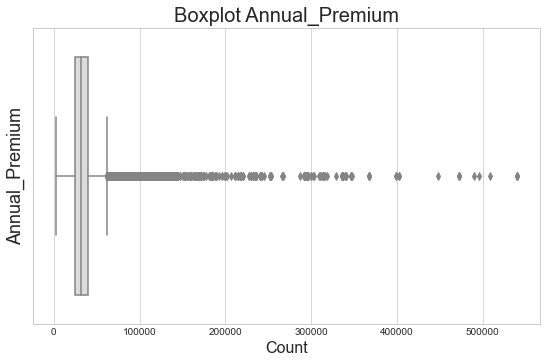

In [20]:
fig, ax = plt.subplots(figsize = (20, 12))

sub1 = plt.subplot(2, 2, 1)
plt.style.use("seaborn-whitegrid")


ax1 = sns.boxplot(x = "Annual_Premium",  data=data, hue = 'Response', palette = "coolwarm")
plt.title("Boxplot Annual_Premium", fontsize = 20)
ax1.set_ylabel("Annual_Premium", fontdict = {'fontsize': 18})
ax1.set_xlabel("Count", fontdict = {'fontsize': 16})
ax1.legend([])

plt.show()

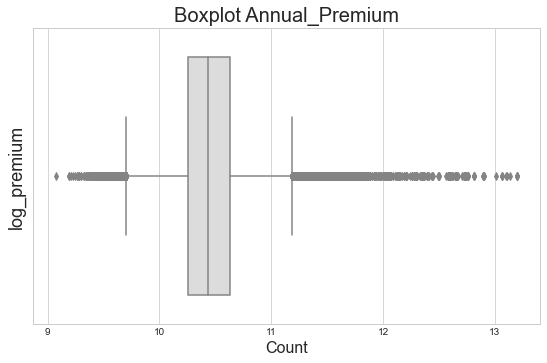

In [18]:
fig, ax = plt.subplots(figsize = (20, 12))

sub1 = plt.subplot(2, 2, 1)
plt.style.use("seaborn-whitegrid")


ax1 = sns.boxplot(x = "log_premium",  data=data_new, hue = 'Response', palette = "coolwarm")
plt.title("Boxplot Annual_Premium", fontsize = 20)
ax1.set_ylabel("log_premium", fontdict = {'fontsize': 18})
ax1.set_xlabel("Count", fontdict = {'fontsize': 16})
ax1.legend([])

plt.show()

/Users/maia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='log_premium', ylabel='Density'>

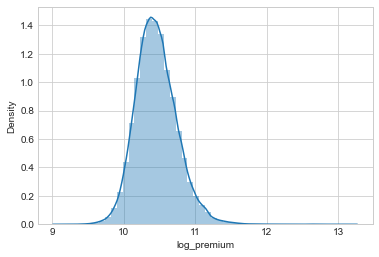

In [19]:
sns.distplot(data_new.log_premium)


In [8]:
data['log_premium'] = np.log(data['Annual_Premium'])

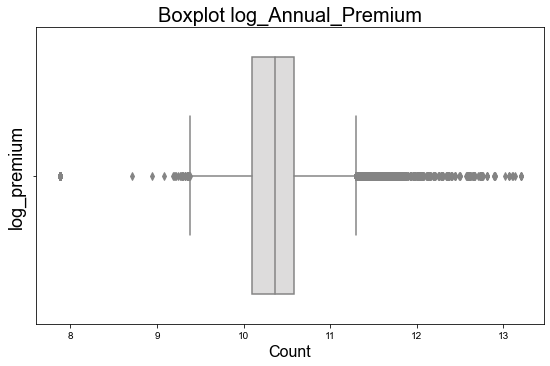

In [9]:
fig, ax = plt.subplots(figsize = (20, 12))

sub1 = plt.subplot(2, 2, 1)
plt.style.use("seaborn-whitegrid")


ax1 = sns.boxplot(x = "log_premium",  data=data, hue = 'Response', palette = "coolwarm")
plt.title("Boxplot log_Annual_Premium", fontsize = 20)
ax1.set_ylabel("log_premium", fontdict = {'fontsize': 18})
ax1.set_xlabel("Count", fontdict = {'fontsize': 16})
ax1.legend([])

plt.show()

In [21]:
data['Vintage'].value_counts() #Number of Days, Customer has been associated with the company 

256    1418
73     1410
282    1397
158    1394
187    1392
       ... 
205    1235
89     1234
32     1230
224    1227
277    1226
Name: Vintage, Length: 290, dtype: int64

<AxesSubplot:>

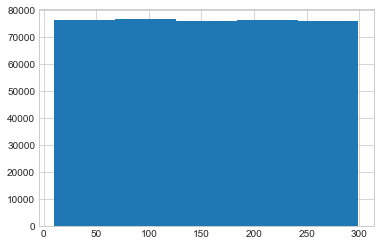

In [24]:
data['Vintage'].hist(bins = 5)

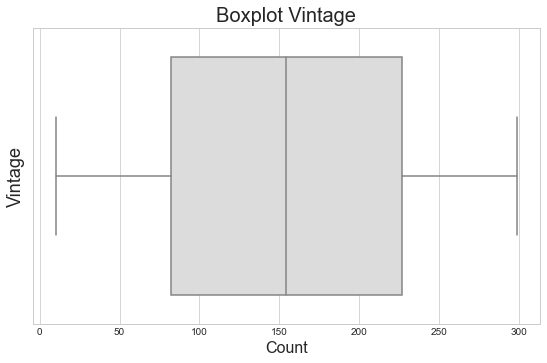

In [70]:
fig, ax = plt.subplots(figsize = (20, 12))

sub1 = plt.subplot(2, 2, 1)
plt.style.use("seaborn-whitegrid")


ax1 = sns.boxplot(x = "Vintage",  data=data, hue = 'Response', palette = "coolwarm")
plt.title("Boxplot Vintage", fontsize = 20)
ax1.set_ylabel("Vintage", fontdict = {'fontsize': 18})
ax1.set_xlabel("Count", fontdict = {'fontsize': 16})
ax1.legend([])

plt.show()

In [22]:
data['Vintage'].describe()

count    381109.000000
mean        154.347397
std          83.671304
min          10.000000
25%          82.000000
50%         154.000000
75%         227.000000
max         299.000000
Name: Vintage, dtype: float64

In [7]:
len(data['Policy_Sales_Channel'].unique())

155

In [24]:
data['Response'].value_counts(normalize = True) * 100

0    87.743664
1    12.256336
Name: Response, dtype: float64

In [54]:
data['Response'] = data['Response'].replace({1: 'Yes', 0: 'No'})


In [ ]:
data_numerical = data[numericals]

In [ ]:
data_numerical.describe()

In [62]:
numericals=['Age', 'Region_Code','Annual_Premium','Vintage']
data_numerical = data[numericals]
categoricals=['Gender','Driving_License','Previously_Insured','Vehicle_Age','Vehicle_Damage','Response']

In [56]:
X = data[categoricals].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Gender              381109 non-null  object
 1   Driving_License     381109 non-null  object
 2   Previously_Insured  381109 non-null  object
 3   Vehicle_Age         381109 non-null  object
 4   Vehicle_Damage      381109 non-null  object
 5   Response            381109 non-null  object
dtypes: object(6)
memory usage: 17.4+ MB


In [57]:
enc = OneHotEncoder(drop = "first")
X = data[categoricals]
enc.fit(X)
enc.categories_



[array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['1-2 Year', '< 1 Year', '> 2 Years'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object)]

In [58]:
dummies = enc.transform(X).toarray()
dummies_df = pd.DataFrame(dummies)
dummies_df

,0,1,2,3,4,5,6
0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
381104,1.0,1.0,1.0,0.0,0.0,0.0,0.0
381105,1.0,1.0,1.0,1.0,0.0,0.0,0.0
381106,1.0,1.0,1.0,1.0,0.0,0.0,0.0
381107,0.0,1.0,0.0,0.0,1.0,1.0,0.0


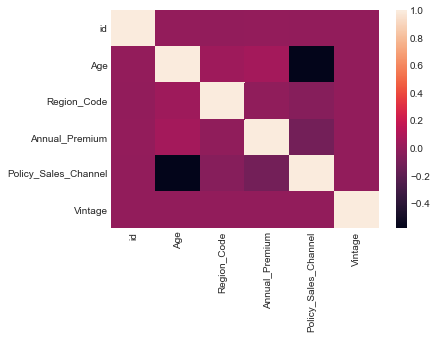

In [75]:
corrMatrix = data.corr()
sns.heatmap(corrMatrix, annot=False, yticklabels='auto')
plt.show()

In [64]:
col_names = [categoricals[i] + '_' + enc.categories_[i] for i in range(len(categoricals))] 
col_names_drop_first = [sublist[i] for sublist in col_names for i in range(len(sublist)) if i != 0]
dummies_df.columns = col_names_drop_first
#We concatenate all of our variables
data_final = pd.concat([dummies_df, data_numerical], axis = 1)
data_final.head()

,Gender_Male,Driving_License_Yes,Previously_Insured_Yes,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Response_Yes,Age,Region_Code,Annual_Premium,Vintage
0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,44,28.0,40454.0,217
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,76,3.0,33536.0,183
2,1.0,1.0,0.0,0.0,1.0,1.0,1.0,47,28.0,38294.0,27
3,1.0,1.0,1.0,1.0,0.0,0.0,0.0,21,11.0,28619.0,203
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,29,41.0,27496.0,39


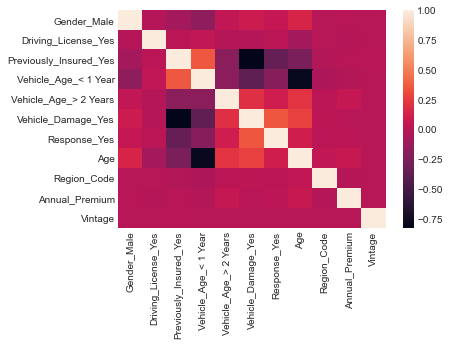

In [66]:
corrMatrix = data_final.corr()
sns.heatmap(corrMatrix, annot=False, yticklabels='auto')
plt.show()

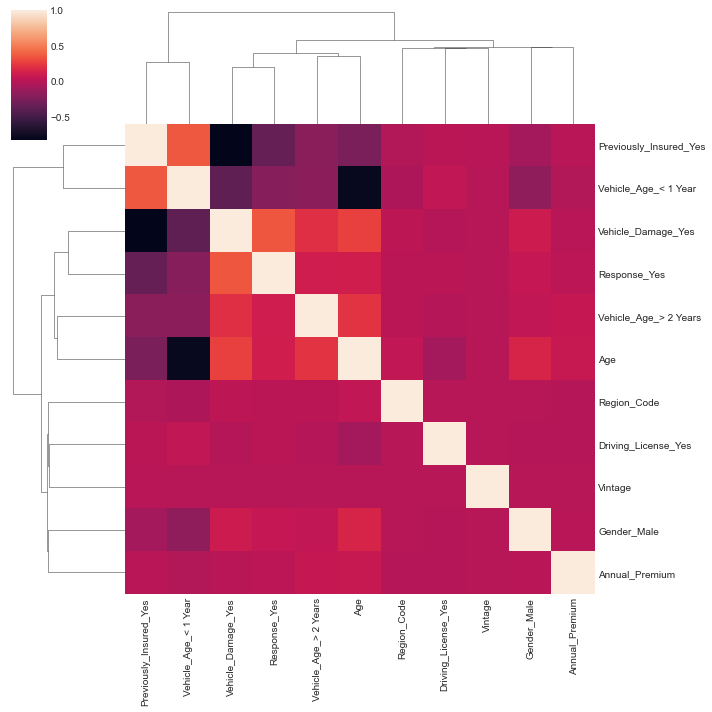

In [67]:
sns.clustermap(corrMatrix);

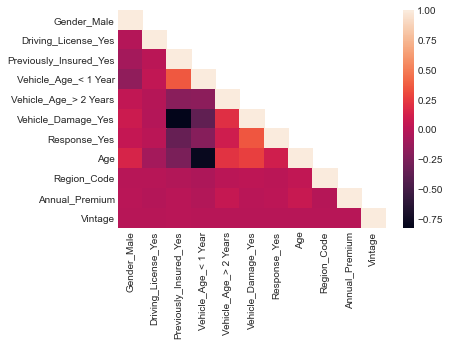

In [68]:
#Upper diagonal (The full matrix has redundant information)
corr_upper = corrMatrix.where(np.tril(np.ones(corrMatrix.shape)).astype(np.bool));
hmap = sns.heatmap(corr_upper);
#hmap.figure.savefig("Correlation_Heatmap_Lower_Triangle_with_Seaborn.png",
                    format='png',
                    dpi=150);

In [69]:
#Find highly correlated pairs

#remove diagonal
np.fill_diagonal(corr_upper.values, 0)

#Find highest correlation pairs sorted
c = corr_upper.abs()
s = c.unstack()
corr_high = s.sort_values(kind="quicksort", ascending=False)[0:5]

print('Pairs of correlated variables ranked:') 
print(corr_high)

Pairs of correlated variables ranked:
Previously_Insured_Yes  Vehicle_Damage_Yes      0.824143
Vehicle_Age_< 1 Year    Age                     0.787775
                        Vehicle_Damage_Yes      0.370778
Previously_Insured_Yes  Vehicle_Age_< 1 Year    0.358773
Vehicle_Damage_Yes      Response_Yes            0.354400
dtype: float64


In [77]:
!pip install -q shap # Run this if you do not have shap installed


In [78]:
import shap


region_code se va?
qué es Policy_Sales_Channel? es categorica, numerica?
target balanceada pero otras features no
graficamos contra target?
qué hacer con annual_premium? son realmente outliers?
Distribución no normal en mayoria features numericas

In [ ]:
age correlacion edad del auto

tiempo auto con edad 
tiempo auto con daño auto
